In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Vil teste:
**Antatte gjennomsnittsverdier** $\mu_y$ og $\mu_z$

**Nullhypotese ($H_0)$:** $\mu_y = \mu_z$.

**Alternativ hypotese ($H_a$):** $\mu_y > \mu_z$.

## To utvalgs t-test

La $n$ være antallet av observasjoner i hver av utvalgene. For oss er $n = 50$.

La $E(y)$ være gjennomsnittet til tallene $y_i$ og la $E(z)$ være gjennomsnittet til tallene $z_i$. 

Vi kommer igjen til å gi en formel for en $t$-verdi som du for eksempel [finner på Wikipedia sin side om t-test i avsnittet "**Equal sample sizes and variance**".](https://en.wikipedia.org/wiki/Student's_t-test)

For å skrive formelen litt fint vil jeg innføre det kombinerte standardavviket
$$\sigma(y,z) = \sqrt{\frac{\sigma(y)^2 + \sigma(z)^2}{2}}.$$

Husk gjerne at standardavviket $\sigma(y)$ er gitt ved formelen $\sigma(y)^2 = E(y^2) - E(y)^2$.

$t$-verdien for vår to utvalgs test er:

$$t = \frac{E(y) - E(z)}{\sigma(y, z) \sqrt{2/n}}.$$

Antallet av frihetsgrader er $2n - 2$.

In [14]:
y = np.array([44257, 41678, 49404, 44049, 37643, 46615, 56040, 52470, 35962,
       30345, 36767, 43413, 19749, 40812, 30540, 35677, 37557, 39836,
       47116, 53425, 41714, 56664, 36348, 46515, 52034, 43940, 35565,
       33782, 38422, 45201, 32903, 40908, 41407, 48408, 45146, 46553,
       36461, 41703, 50839, 57934, 30409, 58139, 56458, 50813, 45644,
       39860, 57580, 62602, 61016, 56151])

In [15]:
z = np.array([43216, 29125, 39959, 45908, 28404, 43556, 43868, 46264, 29342,
       34044, 36072, 29471, 55654, 35536, 42960, 37672, 54251, 51883,
       45700, 20168, 40468, 46153, 49035, 34438, 56398, 28116, 34046,
       48415, 40441, 58021, 41696, 34301, 36601, 30179, 28500, 45673,
       45230, 51651, 33208, 55201, 37413, 54169, 36104, 33380, 42248,
       49283, 41449, 34730, 27929, 27386])

In [16]:
n = len(y)

For å få finere tall regner vi in KNOK, det vil si i tusener av kroner.

In [17]:
y = y /1000
z = z/ 1000

Text(0.5, 1.0, 'Kontrolgruppen med μ = 44 og σ = 9')

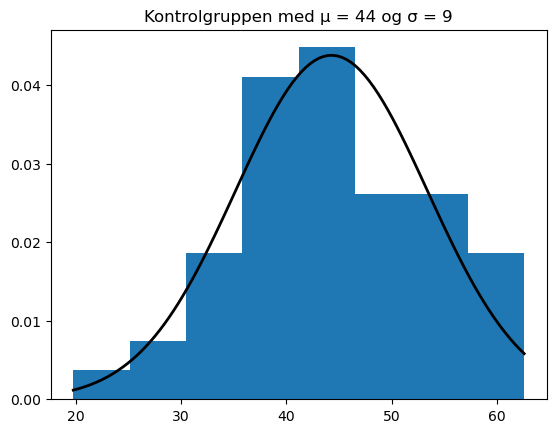

In [18]:

mu, std = scipy.stats.norm.fit(y)
plt.hist(y, bins=8, density=True)
xmin = np.min(y)
xmax = np.max(y)
#xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Kontrolgruppen med μ = {:.0f} og σ = {:.0f}".format(mu, std)
plt.title(title)

Text(0.5, 1.0, 'Inngangsgruppen med μ = 40 og σ = 9')

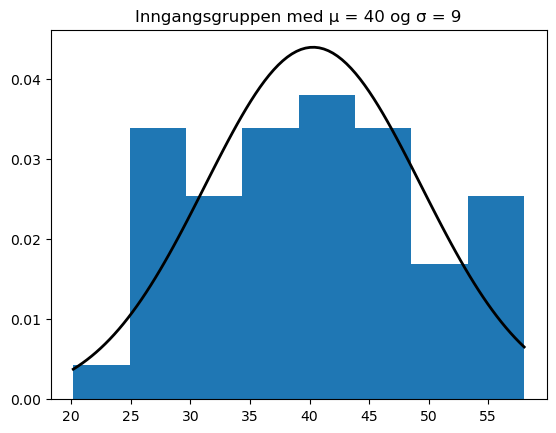

In [20]:
mu, std = scipy.stats.norm.fit(z)
plt.hist(z, bins=8, density=True)
xmin = np.min(z)
xmax = np.max(z)
#xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), scipy.stats.norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Inngangsgruppen med μ = {:.0f} og σ = {:.0f}".format(mu, std)
plt.title(title)

In [22]:
Ey = np.mean(y)
Ez = np.mean(z)
sigmayz = np.sqrt((np.mean(y**2) - Ey**2 + np.mean(z**2) - Ez**2)/2)
t_verdi = (Ey - Ez)/(sigmayz*np.sqrt(2/n))

In [23]:
t_verdi

np.float64(2.1946388405709945)

In [24]:
antall_frihetsgrader = 2*n - 2
float(t_verdi), antall_frihetsgrader

(2.1946388405709945, 98)

In [25]:
# p-verdi
p_verdi = 1 - scipy.stats.t.cdf(t_verdi, df=antall_frihetsgrader)

In [26]:
100 * p_verdi

np.float64(1.5275729088436774)

### **Konklusjon**

Vi kan forkaste nullhypotesen med et konfidensnivå på fem prosent.

Det vil si at godteriet selger best på sin standard plassering ved kassen.

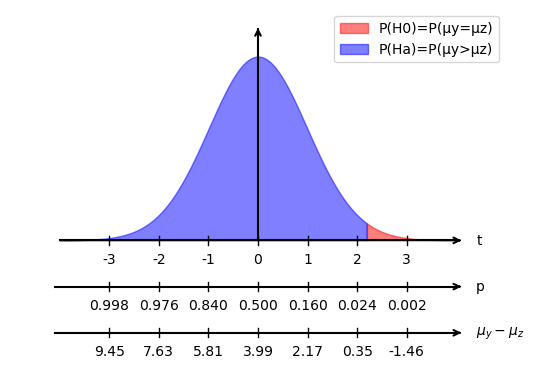

In [34]:
# @title plot

# Define the function
x = np.linspace(-4, 4, 1000)
yy = scipy.stats.t.pdf(x, antall_frihetsgrader)  # t-fordeling med 10 frihetsgrader
t_crit = t_verdi

# def t_av_mu(m):
#     return (Ey - Ez - m)/((sigmayz*np.sqrt(2/n)))

def mu_av_t(t):
    return Ey - Ez - t*((sigmayz*np.sqrt(2/n)))

ax = plt.gca()


plt.fill_between(x, yy, where=(x > t_crit), color='red', alpha=0.5, label=r'P(H0)=P(μy=μz)')
plt.fill_between(x, yy, where=(x < t_crit), color='blue', alpha=0.5, label=r'P(Ha)=P(μy>μz)')
# Remove default spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Set limits
ax.set_xlim(-5, 5)
ax.set_ylim(-.3, .5)  # Ensure axes are visible

# Draw the primary x-axis (for x) with an arrow
ax.plot([-4, 4], [0, 0], color="black", lw=1.5)
ax.annotate("", xy=(4.1, 0), xytext=(4., 0),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, 0, r"t", verticalalignment="center")

# Draw the secondary x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.1, -.1], color="black", lw=1.5)
ax.annotate("", xy=(4.1, -.1), xytext=(4., -.1),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, -.1, r"p", verticalalignment="center")

# Draw the third x-axis (for -x) with an arrow
ax.plot([-4.1, 4], [-.2, -.2], color="black", lw=1.5)
ax.annotate("", xy=(4.1, -.2), xytext=(4., -.2),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
ax.text(4.4, -.2, r"$\mu_y - \mu_z$", verticalalignment="center")

# Draw the y-axis with an arrow
ax.plot([0, 0], [0, .45], color="black", lw=1.5)
ax.annotate("", xy=(0, .46), xytext=(0, .45),
            arrowprops=dict(arrowstyle="->", lw=1.5), annotation_clip=False)
#ax.text(-0.3, .45, r"y", verticalalignment="center")


# Set x-ticks for t-axis
ticks = np.arange(-3, 4, 1)  # Tick positions

# Draw ticks for t-axis
for ti in ticks:
    ax.plot([ti, ti], [-.01, .01], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.05, f"{ti}", fontsize=10, ha="center")  # Labels below ticks

# Draw ticks for p-axis
for ti in ticks:
    p = scipy.stats.t.cdf(-ti, antall_frihetsgrader)
    ax.plot([ti, ti], [-.11, -.09], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.15, f"{p:.3f}", fontsize=10, ha="center")  # Labels below ticks


# Set ticks for μ-axis
# mu_min = mu_av_t(-3)
# mu_maks = mu_av_t(3)
# mu_verdier = np.linspace(mu_min, mu_maks, endpoint=True, num=7)
# muticks = [t_av_mu(mu) for mu in mu_verdier]
# muticks = [mu_av_t(t) for t in ticks]
# Draw ticks for secondary x-axis (-x)
#for t, mu in zip(muticks, mu_verdier):
for ti in ticks:
    ax.plot([ti, ti], [-.21, -.19], color="black", lw=1)  # Small tick marks
    ax.text(ti, -.25, f"{int(1000*mu_av_t(ti))/1000:2.2f}", fontsize=10, ha="center")  # Labels below ticks

# Remove y-ticks
ax.set_yticks([])
ax.set_xticks([])
plt.legend()
plt.savefig('ttilp.png')
plt.show()

